In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RNG = np.random.default_rng(42)

In [13]:
DATA_PATH = "../02_data_processed/TCGA_LUAD_top2000_logCPM_samplesxgenes.csv"
X = pd.read_csv(DATA_PATH, index_col=0)
print("Data shape (samples x genes):", X.shape)

# correlation distance
dist_corr = pdist(X, metric="correlation")
print("Condensed distance length:", len(dist_corr))

Data shape (samples x genes): (540, 2000)
Condensed distance length: 145530


In [14]:
def summarize(name, Z, k_values=(2,3,4,5)):
    print(f"\n=== {name} ===")
    for k in k_values:
        lab = fcluster(Z, k, criterion="maxclust")
        sil = silhouette_score(X, lab, metric="correlation")
        sizes = pd.Series(lab).value_counts().sort_index().to_dict()
        print(f"k={k}: silhouette={sil:.4f}  sizes={sizes}")

Z_avg      = linkage(dist_corr, method="average")
Z_complete = linkage(dist_corr, method="complete")
Z_ward     = linkage(dist_corr, method="ward")

summarize("average (ORIGINAL - degenerate)", Z_avg)
summarize("complete", Z_complete)
summarize("ward.D2 (SELECTED)", Z_ward)


=== average (ORIGINAL - degenerate) ===
k=2: silhouette=0.2379  sizes={1: 527, 2: 13}
k=3: silhouette=0.2067  sizes={1: 527, 2: 2, 3: 11}
k=4: silhouette=0.1897  sizes={1: 515, 2: 12, 3: 2, 4: 11}
k=5: silhouette=0.1476  sizes={1: 515, 2: 12, 3: 2, 4: 3, 5: 8}

=== complete ===
k=2: silhouette=0.0448  sizes={1: 256, 2: 284}
k=3: silhouette=0.0534  sizes={1: 256, 2: 106, 3: 178}
k=4: silhouette=0.0790  sizes={1: 198, 2: 58, 3: 106, 4: 178}
k=5: silhouette=0.0713  sizes={1: 198, 2: 58, 3: 106, 4: 11, 5: 167}

=== ward.D2 (SELECTED) ===
k=2: silhouette=0.1350  sizes={1: 349, 2: 191}
k=3: silhouette=0.1427  sizes={1: 349, 2: 53, 3: 138}
k=4: silhouette=0.1152  sizes={1: 282, 2: 67, 3: 53, 4: 138}
k=5: silhouette=0.0970  sizes={1: 282, 2: 67, 3: 53, 4: 58, 5: 80}


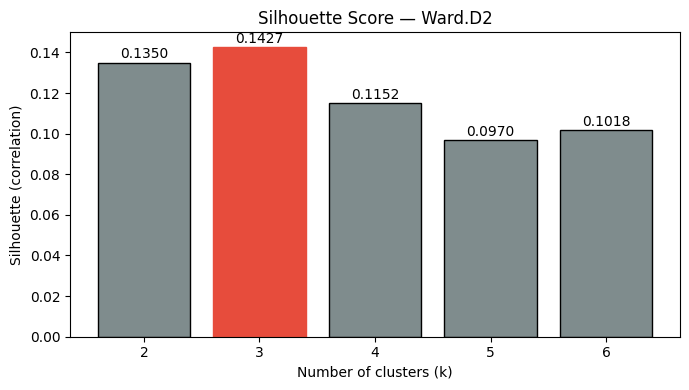

In [15]:
# Silhouette curve for the selected method
ks = [2,3,4,5,6]
sils = []
for k in ks:
    lab = fcluster(Z_ward, k, criterion="maxclust")
    sils.append(silhouette_score(X, lab, metric="correlation"))

plt.figure(figsize=(7,4))
bars = plt.bar([str(k) for k in ks], sils, color="#7f8c8d", edgecolor="k")
bars[int(np.argmax(sils))].set_color("#e74c3c")
for b,s in zip(bars,sils):
    plt.text(b.get_x()+b.get_width()/2, s+0.002, f"{s:.4f}", ha="center")
plt.ylabel("Silhouette (correlation)"); plt.xlabel("Number of clusters (k)")
plt.title("Silhouette Score — Ward.D2"); plt.tight_layout()
plt.savefig("../04_results/silhouette_scores_ward.png", dpi=130)
plt.show()

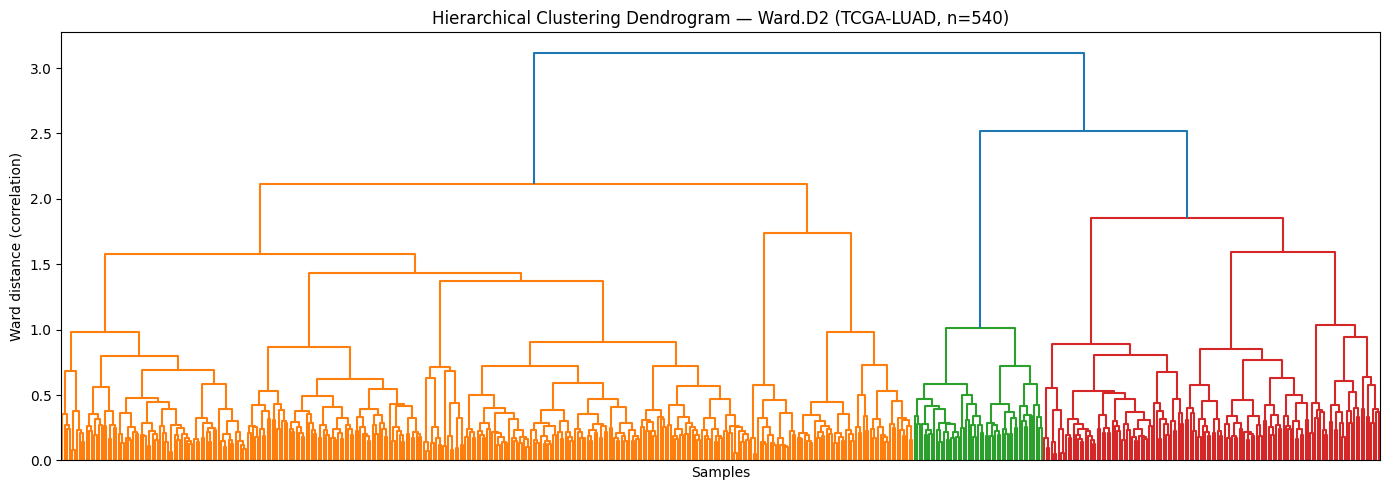

In [16]:
# Dendrogram for the selected method
plt.figure(figsize=(14,5))
dendrogram(Z_ward, no_labels=True, color_threshold=Z_ward[-1,2]*0.7)
plt.title("Hierarchical Clustering Dendrogram — Ward.D2 (TCGA-LUAD, n=540)")
plt.xlabel("Samples"); plt.ylabel("Ward distance (correlation)")
plt.tight_layout()
plt.savefig("../04_results/dendrogram_ward_top2000.png", dpi=110)
plt.show()

In [17]:
n = X.shape[0]
Xv = X.values

def consensus_matrix(k, n_iter=200, frac=0.8):
    M = np.zeros((n, n)); I = np.zeros((n, n))
    for _ in range(n_iter):
        idx = RNG.choice(n, int(frac*n), replace=False)
        Zsub = linkage(pdist(Xv[idx], metric="correlation"), method="ward")
        lab = fcluster(Zsub, k, criterion="maxclust")
        for c in np.unique(lab):
            mem = idx[lab == c]
            M[np.ix_(mem, mem)] += 1
        I[np.ix_(idx, idx)] += 1
    return np.divide(M, I, out=np.zeros_like(M), where=I>0)

def pac(C, low=0.1, high=0.9):
    iu = np.triu_indices_from(C, k=1); v = C[iu]
    return float(np.mean((v > low) & (v < high)))

pac_scores = {}
for k in [2,3,4,5]:
    pac_scores[k] = pac(consensus_matrix(k))
    print(f"k={k}: PAC={pac_scores[k]:.3f}")
print("\nLower PAC = more stable. All values here are high (>0.5) -> unstable structure.")

k=2: PAC=0.785
k=3: PAC=0.713
k=4: PAC=0.596
k=5: PAC=0.513

Lower PAC = more stable. All values here are high (>0.5) -> unstable structure.


karena cluster nya kecil cuman 13, biar ga dikira outlier maka kita validasi cluster kecil

In [18]:
labels_k2 = fcluster(Z_ward, 2, criterion="maxclust")
labels_k3 = fcluster(Z_ward, 3, criterion="maxclust")

cluster_df = pd.DataFrame({
    "sample_id": X.index,
    "cluster":    labels_k2,   # primary = k2, keeps the column name step 5/6 expect
    "cluster_k3": labels_k3,
})
OUT = "../02_data_processed/TCGA_LUAD_cluster_assignment.csv"
cluster_df.to_csv(OUT, index=False)
print("Saved:", OUT)
print("k=2 sizes:", pd.Series(labels_k2).value_counts().sort_index().to_dict())
print("k=3 sizes:", pd.Series(labels_k3).value_counts().sort_index().to_dict())

Saved: ../02_data_processed/TCGA_LUAD_cluster_assignment.csv
k=2 sizes: {1: 349, 2: 191}
k=3 sizes: {1: 349, 2: 53, 3: 138}


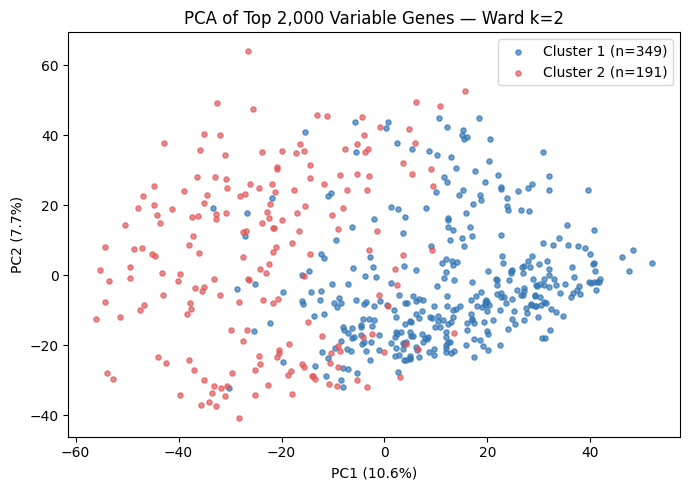

In [19]:
pca = PCA(n_components=2).fit(X.values)
pc = pca.transform(X.values)
plt.figure(figsize=(7,5))
for c, col in zip([1,2], ["#3477b5", "#e15759"]):
    m = labels_k2 == c
    plt.scatter(pc[m,0], pc[m,1], s=14, alpha=0.7, c=col, label=f"Cluster {c} (n={m.sum()})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Top 2,000 Variable Genes — Ward k=2"); plt.legend()
plt.tight_layout()
plt.savefig("../04_results/pca_top2000_ward_k2.png", dpi=130)
plt.show()